<a href="https://colab.research.google.com/github/harjasjolly-create/trading-suggestion-project/blob/main/hypothesis_verifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import yfinance as yf
import pandas as pd
data = yf.download("AAPL", period="54wk", interval="1wk")
import seaborn as sns

/tmp/ipykernel_4535/2807584764.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", period="54wk", interval="1wk")
[*********************100%***********************]  1 of 1 completed


In [4]:
df=pd.DataFrame(data)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 55 entries, 2025-07-28 to 2026-08-10
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   55 non-null     float64
 1   (High, AAPL)    55 non-null     float64
 2   (Low, AAPL)     55 non-null     float64
 3   (Open, AAPL)    55 non-null     float64
 4   (Volume, AAPL)  55 non-null     int64  
dtypes: float64(4), int64(1)
memory usage: 2.6 KB


**BUILDING CHART_ANALYSIS MODEL **

In [5]:
close,high,low,open,volume=df.iloc[:,0],df.iloc[:,1],df.iloc[:,2],df.iloc[:,3],df.iloc[:,4]


**creating simple moving average(sma)** somewhat an average position vector but of closing prices(average closing value fo a batch

In [6]:
sma=close.rolling(window=20).mean()#taking batch of 20 weeks at a time, shifting by 1
sma


,Close
,AAPL
Date,
2025-07-28,NaN
2025-08-04,NaN
2025-08-11,NaN
2025-08-18,NaN
2025-08-25,NaN
2025-09-01,NaN
2025-09-08,NaN
2025-09-15,NaN


[Text(0.5, 0, 'Time'), Text(0, 0.5, 'SMA')]

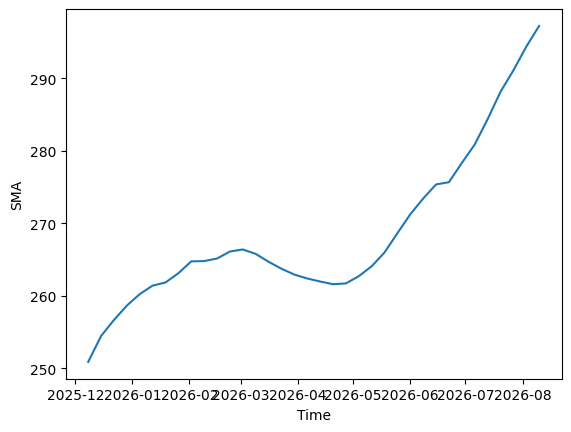

In [7]:
#visualizing sma
sns.lineplot(sma.dropna()).set(xlabel='Time',ylabel='SMA')

**creating average true range(14 candle) (ATR14)**

In [8]:
from os import name
tr1=high-low
#now we need prev timeframe's close value
close_prev=close.shift(1)#since we need prev week closing
tr2=(high-close_prev).abs()
tr3=(low-close_prev).abs()
values=pd.concat([tr1,tr2,tr3],axis=1)
tr_final=values.max(axis=1)
atr14=tr_final.rolling(window=14).mean()
atr14.rename('ATR14',inplace=True)

atr14#so basically average max volatility over 14cweeks batches

,ATR14
Date,
2025-07-28,NaN
2025-08-04,NaN
2025-08-11,NaN
2025-08-18,NaN
2025-08-25,NaN
2025-09-01,NaN
2025-09-08,NaN
2025-09-15,NaN
2025-09-22,NaN


**EMA**

Building ema so as to incorporate recent trends more weighted than past trends , for better accuracy, ill be using ema20 and ema50 with assumption that ema20 moving faaster than ema 50 means bullish trend

In [9]:
ema20=close.ewm(span=20,adjust=False).mean()
ema50=close.ewm(span=50,adjust=False).mean()#weight decreases as day goes more in past
ema_signal=(ema20-ema50)/close#dividing by closing price so as to create a ratio relative to stock price for better classification model training across different stocks
ema_signal

,Close
,AAPL
Date,
2025-07-28,0.000000
2025-08-04,0.006588
2025-08-11,0.012762
2025-08-18,0.017506
2025-08-25,0.022032
2025-09-01,0.027111
2025-09-08,0.031453
2025-09-15,0.035543


[Text(0.5, 0, 'Time'), Text(0, 0.5, 'EMA')]

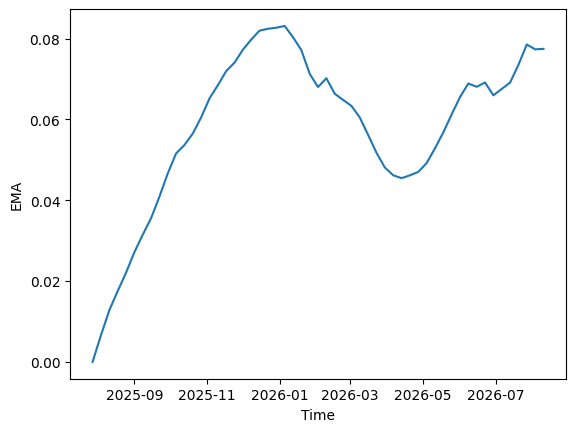

In [10]:
sns.lineplot(ema_signal).set(xlabel='Time',ylabel='EMA')

**Building RSI i.e relative strength of buyers to sellers**, cosidering rsi>50 as bullish,<50 as bearish ,>70 as overbought,<30 as oversold , basically it tells what poercentage of price movements is bullish

[Text(0.5, 0, 'Time'), Text(0, 0.5, 'RSI')]

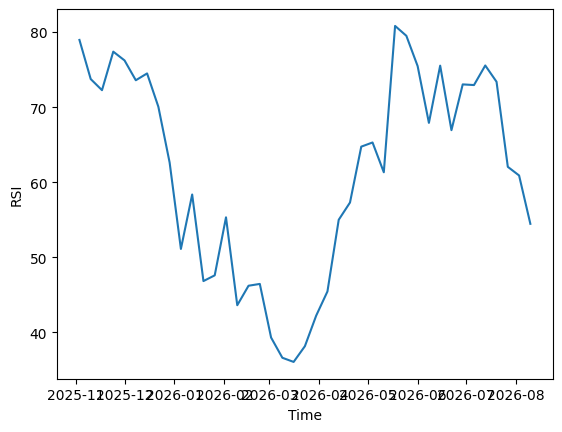

In [11]:
delta=close.diff()# calculating price change
gain=delta.clip(lower=0).rolling(14).mean()
loss=-delta.clip(upper=0).rolling(14).mean()
rs=gain/loss
#normalising rs from 0 ro 100 instead of 0 to infinity
rsi=100-100/(1+rs)
sns.lineplot(rsi).set(xlabel='Time',ylabel='RSI')

note: each rolling code requires actual entires so initial and final value might be considered nan output, as im currently using 54 week data, we can increase it to create a better model

**Building support resistance levels**

firstly, building swing highs and swing lows thats local highs and lows over 7 week windows

In [12]:
df["is_swing_high"]=(high==high.rolling(7,center=True).max())
df["is_swing_low"]=(low==low.rolling(7,center=True).min())
swing_high=df.loc[df['is_swing_high'],('High','AAPL')]
swing_low=df.loc[df["is_swing_low"],('Low','AAPL')]


now, we need to cluster swing highs and lows that are almost nearby so as to create the support and resistance levels but the zone width to consider two lows in same cluster is dependent on the volatility of stock  so well use atr for this ans assume a safe zone width of atr*0.5 so the lows can be within 50% of volatility at that time and hence considered the same lows and if 2 lows fall into a cluster, then that will be the support

In [13]:
atr_multiplier=0.5

In [14]:
support_df=pd.concat([swing_low,atr14],axis=1).dropna()
support_df


,"(Low, AAPL)",ATR14
Date,,
2026-01-19,242.759215,10.319516
2026-03-30,245.072652,13.001510
2026-06-22,273.514106,15.877309


In [15]:
#converting to list of dictionaries so that i can pop without any index error and also itll increase speed as dataframes are slow in delecting rows and looping over them (though they are fast at simukltaneous math)
swinglows=support_df.to_dict('records')#using record so that it created dictionary liost row wise and not column wise(record and row are same things)
swinglows


[{('Low', 'AAPL'): 242.75921493368202, 'ATR14': 10.31951580409614},
 {('Low', 'AAPL'): 245.07265167866177, 'ATR14': 13.001509704514573},
 {('Low', 'AAPL'): 273.51410564235374, 'ATR14': 15.877309275574545}]

In [16]:
true_support=[]
while len(swinglows)>0:
  base_item = swinglows.pop(0)
  base_price = base_item[('Low', 'AAPL')]
  base_atr = base_item['ATR14']
  zone_width=atr_multiplier*base_atr
  potential_support=[base_price]
  remaining=[]
  for rest in swinglows:
    if abs(rest[('Low', 'AAPL')]-base_price)<=zone_width:
      potential_support.append(rest[('Low', 'AAPL')])
    else:
      remaining.append(rest)
  swinglows=remaining
  if len(potential_support)>=2:
    avg_support=sum(potential_support)/len(potential_support)
    true_support.append(avg_support)


In [17]:
true_support

[243.9159333061719]

In [18]:
#now coding true_resistance

In [19]:
resistance_df=pd.concat([swing_high,atr14],axis=1).dropna()
resistance_df

,"(High, AAPL)",ATR14
Date,,
2025-10-27,276.299373,12.819296
2025-12-01,287.836509,11.305386
2026-02-02,280.147425,10.899126
2026-06-08,317.126504,14.625509


In [20]:
swinghighs=resistance_df.to_dict('records')
true_resistance=[]
while len(swinghighs)>0:
  top_item = swinghighs.pop(0)
  top_price = top_item[('High', 'AAPL')]
  top_atr = top_item['ATR14']
  zone_width=atr_multiplier*top_atr
  potential_resistance=[top_price]
  remaining=[]
  for rest in swinghighs:
    if abs(rest[('High', 'AAPL')]-top_price)<=zone_width:
      potential_resistance.append(rest[('High', 'AAPL')])
    else:
      remaining.append(rest)
  swinghighs=remaining
  if len(potential_resistance)>=2:

    avg_resistance=sum(potential_resistance)/len(potential_resistance)
    true_resistance.append(avg_resistance)




In [21]:
true_resistance

[278.223398756993]

**finding y for further modelling**

In [22]:
# ill be using triple barrier method for stock_execution score and alpha for stock_alpha score so as to check strength relative to benchmark
#ill use s&p 500 returns as benchmark


**triple barrier**

In [32]:

stock_data=pd.concat([close,atr14],axis=1)
#using name upper amnd lower barrier instead of target and stop loss so as to justify the name triple barrier;)

In [35]:
stock_data['upper_barrier']=stock_data[('Close', 'AAPL')]+stock_data['ATR14']*2
stock_data['lower_barrier']=stock_data[('Close', 'AAPL')]-stock_data['ATR14']*1
stock_data.sample(5)

,"(Close, AAPL)",ATR14,upper_barrier,lower_barrier
Date,,,,
2025-08-18,226.921753,NaN,NaN,NaN
2025-11-24,278.093048,11.036943,300.166934,267.056105
2025-11-10,271.670502,11.043420,293.757342,260.627082
2026-04-20,270.577118,13.785072,298.147261,256.792046
2026-07-27,308.643829,20.161275,348.966379,288.482554


In [91]:
#lets use time barrier of 2 weeks
stock_data["shifted_close"]=stock_data[('Close', 'AAPL')].shift(-2)


In [101]:
#now giving score of +1,-1 and 0 accordingly
import numpy as np
conditions=[(stock_data["shifted_close"]>=stock_data['upper_barrier']),(stock_data["shifted_close"]<=stock_data['lower_barrier'])]
choices=[1,-1]
stock_data["exec_score"]=np.select(conditions,choices,default=0)
stock_data.sample(5)


,"(Close, AAPL)",ATR14,upper_barrier,lower_barrier,exec_score,shifted_close
Date,,,,,,
2026-05-25,311.791107,13.442002,338.675111,298.349105,-1,290.879150
2026-02-23,263.709381,12.522064,288.753509,251.187317,-1,249.674438
2026-06-22,283.535461,15.877309,315.290080,267.658152,0,315.048309
2025-10-20,261.852722,NaN,NaN,NaN,0,267.481903
2026-03-02,257.001343,12.713783,282.428909,244.287560,0,247.548233


**now the benchmark comparison that is alpha score**

In [107]:
snp_data=yf.download("^GSPC",period="54wk",interval="1wk")
snp_close=pd.DataFrame(snp_data).iloc[:,0]
snp_close.info()

/tmp/ipykernel_4535/520086488.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  snp_data=yf.download("^GSPC",period="54wk",interval="1wk")
[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.series.Series'>
DatetimeIndex: 55 entries, 2025-07-28 to 2026-08-10
Series name: ('Close', '^GSPC')
Non-Null Count  Dtype  
--------------  -----  
55 non-null     float64
dtypes: float64(1)
memory usage: 880.0 bytes


In [115]:
#now comparison
#ill be using 2 week timeframe for return comparison
stock_data['stock_return_2wk']=(stock_data['shifted_close']-stock_data[('Close', 'AAPL')])/stock_data[('Close', 'AAPL')]
snp_data['shifted_close']=snp_close.shift(-2)
stock_data['snp_return_2wk']=(snp_data['shifted_close']-snp_data[('Close', '^GSPC')])/snp_data[('Close', '^GSPC')]
stock_data['aplha']=stock_data['stock_return_2wk']-stock_data['snp_return_2wk']
#considering a buffer oif 0.5% so as to remove buffer as if alpha is 0.2% more than benchmark, it isnt really a great winner but similiar to 0 so just a noise so well consider it as 0
conditions=[(stock_data['aplha']>0.005),stock_data['aplha']<0.005]
choices=[1,-1]
stock_data["alpha_score"]=np.select(conditions,choices,default=0)
stock_data['alpha_score'].head()

,alpha_score
Date,
2025-07-28,1
2025-08-04,-1
2025-08-11,-1
2025-08-18,1
2025-08-25,-1


**now creating a score based on support resitance , considering if close is within 1%of support or resistance, then well consider the actual +-1 score else iot wopnt really matter and hence 0**


In [ ]:
#true_support
#true_resistance
